In [11]:
import shutil
import tensorflow as tf

src = "/kaggle/input/models/namthanh2006/model-potato/keras/default/1/potato (1).keras"
dst = "/kaggle/working/potato.h5"

shutil.copy(src, dst)

model = tf.keras.models.load_model(dst, compile=False)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 64)   │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 346,176 (1.32 MB)

 Trainable params: 346,176 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
Raw prediction: [7.7859417e-04 9.9922144e-01 1.9607911e-09]
Predicted class: Potato___Late_blight
Confidence: 99.92%


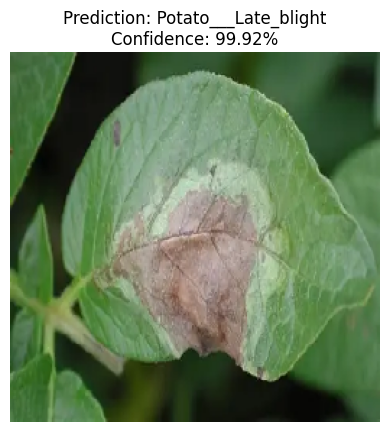

In [13]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# ===== CLASS NAMES =====
class_names = [
    "Potato___Early_blight", #0
    "Potato___Late_blight", #1
    "Potato___healthy" #2
]

# ===== IMAGE PATH =====
img_path = ""

# ===== LOAD IMAGE =====
img = image.load_img(img_path, target_size=(256,256))
img_array = image.img_to_array(img)

input_img = np.expand_dims(img_array, 0)

# ===== PREDICT =====
pred = model.predict(input_img)

probs = pred[0][:3]

pred_class = np.argmax(probs)
confidence = probs[pred_class] * 100

# ===== PRINT RESULT =====
print("Raw prediction:", probs)
print("Predicted class:", class_names[pred_class])
print(f"Confidence: {confidence:.2f}%")

# ===== SHOW IMAGE =====
plt.imshow(img_array.astype("uint8"))
plt.title(f"Prediction: {class_names[pred_class]}\nConfidence: {confidence:.2f}%")
plt.axis("off")
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import os
import random
import matplotlib.pyplot as plt

# ===== LOAD MODEL =====
model = tf.keras.models.load_model("/kaggle/working/potato.keras")

# ===== DATASET PATH =====
dataset_path = "/kaggle/working"

classes = [
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy"
]

img_size = (256,256)

# ===== COLLECT IMAGES =====
images = []
labels = []

for i, cls in enumerate(classes):

    folder = os.path.join(dataset_path, cls)

    for img in os.listdir(folder):
        images.append(os.path.join(folder, img))
        labels.append(i)

# ===== PICK RANDOM 5 =====
indices = random.sample(range(len(images)), 5)

plt.figure(figsize=(12,6))

for i, idx in enumerate(indices):

    img_path = images[idx]
    true_label = labels[idx]

    # load image
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)

    input_img = np.expand_dims(img_array, 0)

    # predict
    pred = model.predict(input_img, verbose=0)

    # lấy 3 class đầu (model output 64)
    pred_class = np.argmax(pred[0][:3])

    # plot
    plt.subplot(1,5,i+1)
    plt.imshow(img_array.astype("uint8"))
    plt.title(
        f"True: {classes[true_label].split('___')[1]}\nPred: {classes[pred_class].split('___')[1]}"
    )
    plt.axis("off")

plt.show()